# Exploration of DenseNet algorithm for image classification

DenseNet: This is a model of the CNN class, but it has the advantage that the model provides the connection of one layer to all the rest in the dense blocks. This is done in a feed-forward manner. This means that, the output of one layer is also feed to the rest of the layers.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

project_path = '/content/drive/MyDrive/cnn_project'
os.makedirs(project_path, exist_ok=True)

## Importing relevant libraries

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, metrics, utils, preprocessing
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from keras.optimizers import Adam
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import  Flatten, Dense, Dropout, Rescaling, Lambda, Input, Resizing, GlobalAveragePooling2D
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

In [19]:
#Calling the Keras API: Densenet121
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input

In [5]:
#Relevant functions
def call_info_ds(ds, ds_name=None):
  '''
  This function is to organize the printed information about the shape and type of datasets.

  '''
  print("====================")
  print("Dataset|Shape|type")
  print("====================")
  print(f"{ds_name}|{ds.shape}|{ds.dtype}")


## Importing dataset

In [5]:
#Data should be pre-split in the original dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 183s 1us/step


In [6]:
#Class names
class_names = ['Airplane','Automobile','Bird','Cat','Deer','Dog','Frog','Horse','Ship','Truck']

### Workflow
1. Preprocessing data: DenseNet121 suggests (244x244x3) however, it also accepts the cifar10 data as is, because the values should not be smaller than 32. To improve the data the images will be resized to 96x96.
2. Setting up the model architecture, which must have the output matching the 10 features from the dataset.
2. Parameters: batch size of 64, 100 epochs, learning rate is 0.001.

## Data preprocessing

In [7]:
import numpy as np
#Saving data as copy
X_train = np.copy(x_train)
X_test = np.copy(x_test)

#One hot encoding y
y_train_cat = tf.one_hot(tf.squeeze(y_train), depth=10)
y_test_cat = tf.one_hot(tf.squeeze(y_test), depth=10)

## Model v1.Baseline

### Model Architecture

In [14]:
#Building the transfer learning model
img_height = 96
img_width = 96
base_model_v1= DenseNet121(include_top=False, weights ="imagenet", input_shape = (img_height,img_width,3), pooling = "avg")

# Freeze pretrained layers
base_model_v1.trainable = False

model_v1 = models.Sequential([
    Input(shape = (32,32,3)),#Indicating the input size of original images
    Resizing(96,96),
    Lambda(preprocess_input),
    base_model_v1,
    Dense(64, activation='relu'),#Adding a fully connected layer
    Dense(10, activation ="softmax"), #Selecting output to be the size of the classes
])
#Printing model summary
model_v1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_1 (Resizing)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 1024)           │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,103,754 (27.10 MB)

 Trainable params: 66,250 (258.79 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [15]:
#Defining the compiler for the model
opt = tf.keras.optimizers.Adam(
    learning_rate=0.001,
    epsilon=1e-07)
model_v1.compile(optimizer=opt,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

### Model Training

In [16]:
#Controling and training the model
checkpoint = ModelCheckpoint(
    filepath=f'{project_path}/checkpoints/densenet1/best_model.keras',
    save_best_only=True,  # only saves if model improved
    monitor='val_accuracy',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=5,        # stops if no improvement for 5 epochs
    restore_best_weights=True,  # rolls back to best weights when stopping
    verbose=1
)

reduce_lr = ReduceLROnPlateau( monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1 )

history_v1= model_v1.fit(X_train, y_train_cat,
          validation_split=0.2, # Keras takes the last 20% of X_train automatically
          epochs=100, # set high — early stopping will interrupt,
          batch_size=64,
          callbacks=[checkpoint, early_stopping, reduce_lr]
          )


Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7173 - loss: 0.8908
Epoch 1: val_accuracy improved from None to 0.84340, saving model to /content/drive/MyDrive/cnn_project/checkpoints/densenet1/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/densenet1/best_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 74s 78ms/step - accuracy: 0.8015 - loss: 0.5992 - val_accuracy: 0.8434 - val_loss: 0.4614 - learning_rate: 0.0010
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8631 - loss: 0.4001
Epoch 2: val_accuracy improved from 0.84340 to 0.85980, saving model to /content/drive/MyDrive/cnn_project/checkpoints/densenet1/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/densenet1/best_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - accuracy: 0.8628 - loss: 0.3994 - val_accuracy: 0.8598 - val_loss: 0.4172 - learning_rate: 0.0010
Epoch 3/100
625/625 ━━━━━━━━━━━

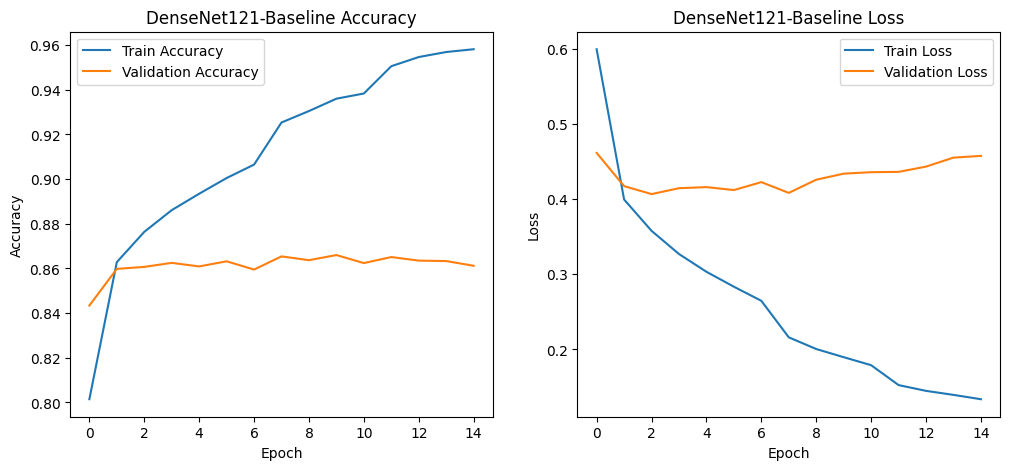

In [19]:
#Plotting results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_v1.history['accuracy'], label='Train Accuracy')
plt.plot(history_v1.history['val_accuracy'], label='Validation Accuracy')
plt.title('DenseNet121-Baseline Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_v1.history['loss'], label='Train Loss')
plt.plot(history_v1.history['val_loss'], label='Validation Loss')
plt.title('DenseNet121-Baseline Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.savefig(f"{project_path}/figures/DenseNet/BaselineCurves.png")
plt.show()

### Evaluation

In [20]:
## Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# Predict class probabilities
y_pred_probs = model_v1.predict(X_test)

# Convert probabilities to class predictions
y_pred = y_pred_probs.argmax(axis=1)
y_true = y_test  # original integer labels

# Compute metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 32s 59ms/step
Accuracy: 0.8552
Precision: 0.8586
Recall: 0.8552
F1 Score: 0.8556


In [21]:
from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

              precision    recall  f1-score   support

    Airplane       0.86      0.88      0.87      1000
  Automobile       0.89      0.93      0.91      1000
        Bird       0.88      0.79      0.83      1000
         Cat       0.71      0.81      0.76      1000
        Deer       0.80      0.84      0.82      1000
         Dog       0.85      0.76      0.80      1000
        Frog       0.83      0.91      0.87      1000
       Horse       0.93      0.84      0.88      1000
        Ship       0.93      0.90      0.91      1000
       Truck       0.91      0.89      0.90      1000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step


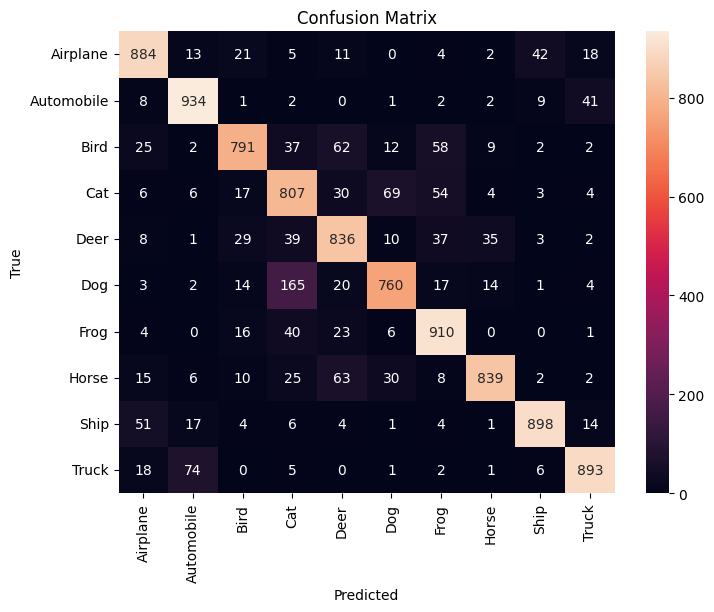

In [22]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Predict & confusion matrix
y_pred = model_v1.predict(X_test).argmax(axis=1)
cm_v1 = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm_v1, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

### Evaluation on test data

In [23]:
## Final result on evaluation

loss_v1, accuracy_v1 = model_v1.evaluate(X_test, y_test_cat)
print(f"Test accuracy of baseline model: {accuracy_v1:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.8552 - loss: 0.4686
Test accuracy of baseline model: 0.8552


Conclusion: This model is heavily underfitting images, mostly confusing cats and dogs.

## Model v2_aug: Data augmentation

### Modification

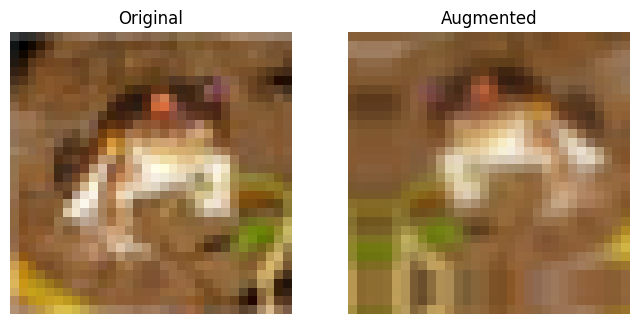

In [27]:
# Setup data augmentation as a layer

data_augmentation = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1,0.1),
])
image = X_train[0]

# Add batch dimension
image_batch = tf.expand_dims(image, axis=0)

# Apply augmentation
augmented_image = data_augmentation(image_batch)

# Remove batch dimension
augmented_image = augmented_image[0]
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

# Original
plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

# Augmented
plt.subplot(1,2,2)
plt.imshow(augmented_image.numpy().astype("uint8"))
plt.title("Augmented")
plt.axis("off")

plt.show()


### Model Architecture

In [21]:
#Building the transfer learning model
img_height = 96
img_width = 96
base_model_v2 = DenseNet121(include_top=False, weights ="imagenet", input_shape = (img_height,img_width,3), pooling = "avg")
# Freeze pretrained layers
base_model_v2.trainable = False
model_v2_aug = models.Sequential([
    Input(shape = (32,32,3)),#Indicating the input size of original images
    Resizing(96,96),
    data_augmentation,
    Lambda(preprocess_input),
    base_model_v2,
    Dense(128, activation='relu'),#Adding a fully connected layer
    Dense(10, activation ="softmax"), #Selecting output to be the size of the classes
])
#Printing model summary
model_v2_aug.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_1 (Resizing)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 1024)           │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,169,994 (27.35 MB)

 Trainable params: 132,490 (517.54 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [22]:
#Defining the compiler for the model
opt = tf.keras.optimizers.Adam(
    learning_rate=0.001,
    epsilon=1e-07)
model_v2_aug.compile(optimizer=opt,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

### Model training

In [23]:
#Controling and training the model
checkpoint = ModelCheckpoint(
    filepath=f'{project_path}/checkpoints/densenet2_aug/best_model.keras',
    save_best_only=True,  # only saves if model improved
    monitor='val_accuracy',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=5,        # stops if no improvement for 5 epochs
    restore_best_weights=True,  # rolls back to best weights when stopping
    verbose=1
)

reduce_lr = ReduceLROnPlateau( monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1 )


history_v2_aug= model_v2_aug.fit(X_train, y_train_cat,
          validation_split = 0.2,
          epochs=100, # set high — early stopping will interrupt,
          batch_size=64,
          callbacks=[checkpoint, early_stopping, reduce_lr]
          )

Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.6410 - loss: 1.0975
Epoch 1: val_accuracy improved from None to 0.81850, saving model to /content/drive/MyDrive/cnn_project/checkpoints/densenet2_aug/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/densenet2_aug/best_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 72s 92ms/step - accuracy: 0.7090 - loss: 0.8541 - val_accuracy: 0.8185 - val_loss: 0.5205 - learning_rate: 0.0010
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.7606 - loss: 0.6802
Epoch 2: val_accuracy improved from 0.81850 to 0.82990, saving model to /content/drive/MyDrive/cnn_project/checkpoints/densenet2_aug/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/densenet2_aug/best_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 49s 78ms/step - accuracy: 0.7639 - loss: 0.6716 - val_accuracy: 0.8299 - val_loss: 0.4935 - learning_rate: 0.0010
Epoch 3/100
625

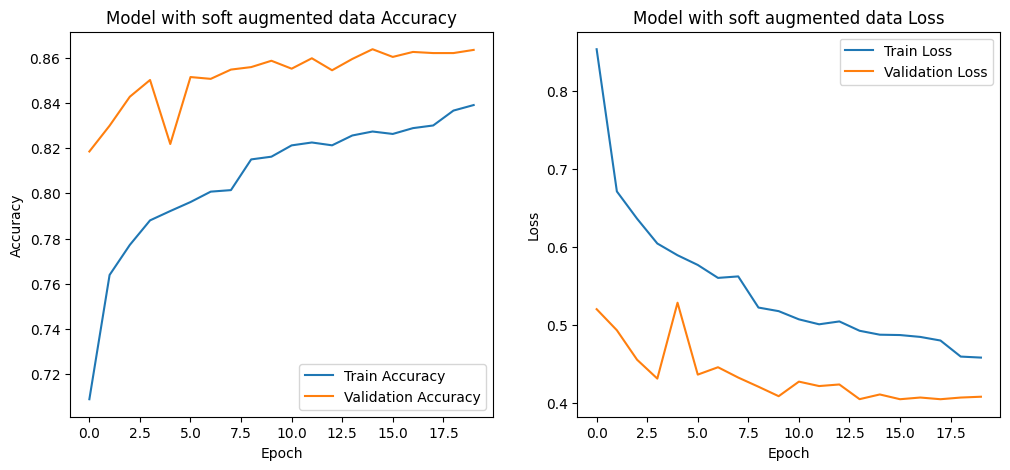

In [24]:
#Plotting results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_v2_aug.history['accuracy'], label='Train Accuracy')
plt.plot(history_v2_aug.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model with soft augmented data Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_v2_aug.history['loss'], label='Train Loss')
plt.plot(history_v2_aug.history['val_loss'], label='Validation Loss')
plt.title('Model with soft augmented data Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Model Evaluation

In [25]:
## Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# Predict class probabilities
y_pred_probs = model_v2_aug.predict(X_test)

# Convert probabilities to class predictions
y_pred = y_pred_probs.argmax(axis=1)
y_true = y_test  # original integer labels

# Compute metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 44ms/step
Accuracy: 0.8542
Precision: 0.8559
Recall: 0.8542
F1 Score: 0.8530


In [26]:
from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

              precision    recall  f1-score   support

    Airplane       0.86      0.85      0.86      1000
  Automobile       0.86      0.94      0.90      1000
        Bird       0.91      0.79      0.85      1000
         Cat       0.83      0.70      0.76      1000
        Deer       0.79      0.83      0.81      1000
         Dog       0.86      0.80      0.83      1000
        Frog       0.81      0.94      0.87      1000
       Horse       0.88      0.88      0.88      1000
        Ship       0.85      0.94      0.89      1000
       Truck       0.92      0.86      0.89      1000

    accuracy                           0.85     10000
   macro avg       0.86      0.85      0.85     10000
weighted avg       0.86      0.85      0.85     10000



### Evaluation of test data

In [27]:
## Final result on evaluation

loss_v2_aug, accuracy_v2_aug = model_v2_aug.evaluate(X_test, y_test_cat)
print(f"Test accuracy of baseline model: {accuracy_v2_aug:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.8542 - loss: 0.4278
Test accuracy of baseline model: 0.8542


## Model v2.2 Decreasing the augmentation

In [20]:
data_augmentationv2 = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomTranslation(0.05,0.05),
])

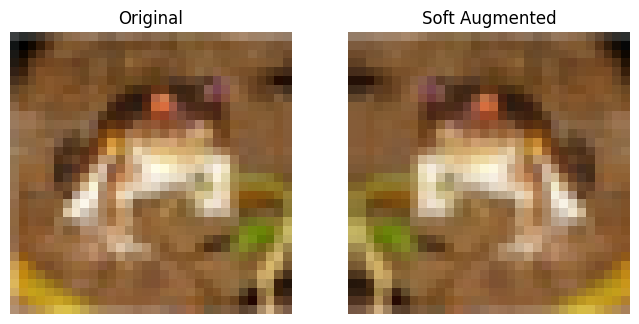

In [14]:
image2 = X_train[0]

# Add batch dimension
image_batch2 = tf.expand_dims(image2, axis=0)

# Apply augmentation
augmented_image2 = data_augmentationv2(image_batch2)

# Remove batch dimension
augmented_image2 = augmented_image2[0]
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

# Original
plt.subplot(1,2,1)
plt.imshow(image2)
plt.title("Original")
plt.axis("off")

# Augmented
plt.subplot(1,2,2)
plt.imshow(augmented_image2.numpy().astype("uint8"))
plt.title("Soft Augmented")
plt.axis("off")

plt.show()

In [21]:
#Building the transfer learning model
img_height = 96
img_width = 96
base_model_v21 = DenseNet121(include_top=False, weights ="imagenet",pooling = "avg")
# Freeze pretrained layers
base_model_v21.trainable = False
model_v21_softaug = models.Sequential([
    Input(shape = (32,32,3)),#Indicating the input size of original images
    Resizing(96,96),
    data_augmentationv2,
    Lambda(preprocess_input),
    base_model_v21,
    Dense(64, activation='relu'),#Adding a fully connected layer
    Dense(10, activation ="softmax"), #Selecting output to be the size of the classes
])
#Defining the compiler for the model
opt = tf.keras.optimizers.Adam(
    learning_rate=0.001,
    epsilon=1e-07)
model_v21_softaug.compile(optimizer=opt,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

#Printing model summary
model_v21_softaug.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_4 (Resizing)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_5 (Sequential)       │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_4 (Lambda)               │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 1024)           │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,103,754 (27.10 MB)

 Trainable params: 66,250 (258.79 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [22]:
#Controling and training the model
checkpoint = ModelCheckpoint(
    filepath=f'{project_path}/checkpoints/densenet2v21_softaug/best_model.keras',
    save_best_only=True,  # only saves if model improved
    monitor='val_accuracy',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=5,        # stops if no improvement for 5 epochs
    restore_best_weights=True,  # rolls back to best weights when stopping
    verbose=1
)

reduce_lr = ReduceLROnPlateau( monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1 )


history_v21_softaug= model_v21_softaug.fit(X_train, y_train_cat,
          validation_split = 0.2,
          epochs=100, # set high — early stopping will interrupt,
          batch_size=64,
          callbacks=[checkpoint, early_stopping, reduce_lr]
          )

Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.7113 - loss: 0.9064
Epoch 1: val_accuracy improved from None to 0.84270, saving model to /content/drive/MyDrive/cnn_project/checkpoints/densenet2v21_softaug/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/densenet2v21_softaug/best_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 71s 89ms/step - accuracy: 0.7955 - loss: 0.6172 - val_accuracy: 0.8427 - val_loss: 0.4572 - learning_rate: 0.0010
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.8543 - loss: 0.4247
Epoch 2: val_accuracy improved from 0.84270 to 0.85530, saving model to /content/drive/MyDrive/cnn_project/checkpoints/densenet2v21_softaug/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/densenet2v21_softaug/best_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 49s 79ms/step - accuracy: 0.8548 - loss: 0.4237 - val_accuracy: 0.8553 - val_loss: 0.4313 - learning_

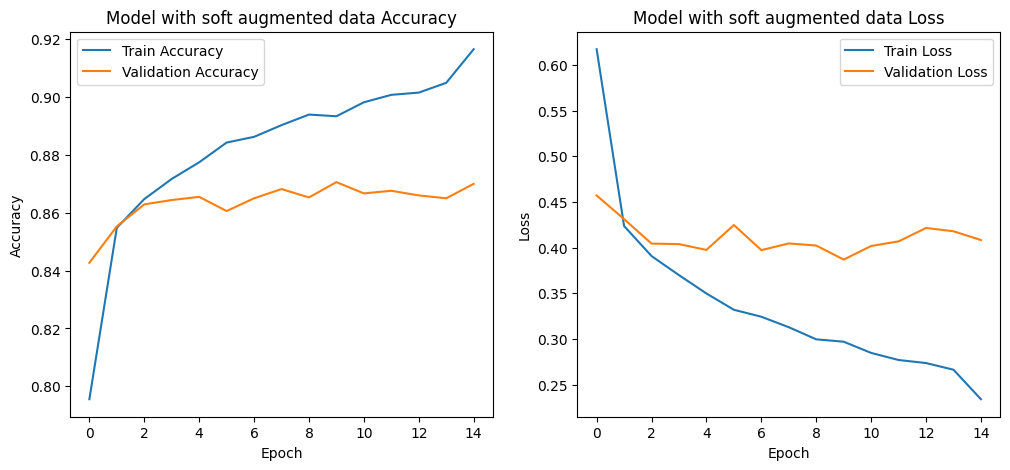

In [46]:
#Plotting results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_v21_softaug.history['accuracy'], label='Train Accuracy')
plt.plot(history_v21_softaug.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model with soft augmented data Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_v21_softaug.history['loss'], label='Train Loss')
plt.plot(history_v21_softaug.history['val_loss'], label='Validation Loss')
plt.title('Model with soft augmented data Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [23]:
## Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# Predict class probabilities
y_pred_probs = model_v21_softaug.predict(X_test)

# Convert probabilities to class predictions
y_pred = y_pred_probs.argmax(axis=1)
y_true = y_test  # original integer labels

# Compute metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 45ms/step
Accuracy: 0.8643
Precision: 0.8650
Recall: 0.8643
F1 Score: 0.8642


313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step


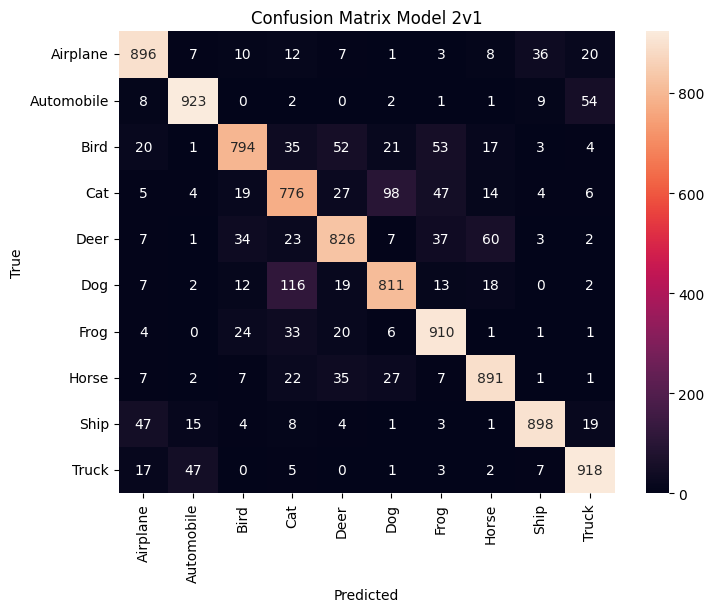

In [27]:
#Confusion matrix
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
# Predict & confusion matrix
y_pred = model_v21_softaug.predict(X_test).argmax(axis=1)
cm_v21 = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm_v21, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix Model 2v1')
plt.savefig(f"{project_path}/figures/DenseNet/DenseNetv21_Confusionmatrix.png")
plt.show()

In [28]:
class_names

['Airplane',
 'Automobile',
 'Bird',
 'Cat',
 'Deer',
 'Dog',
 'Frog',
 'Horse',
 'Ship',
 'Truck']

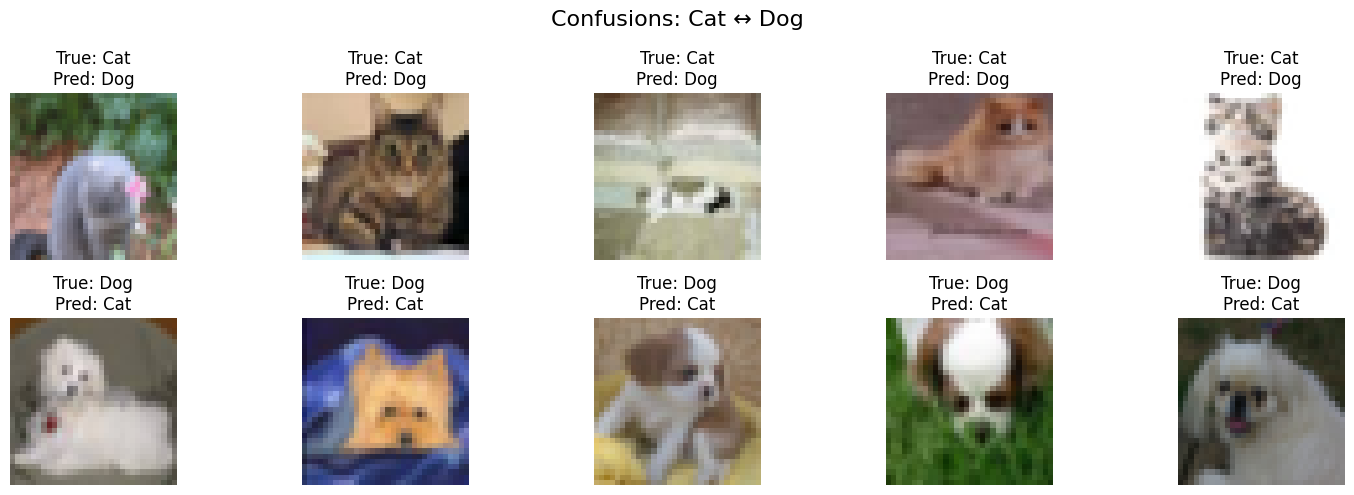

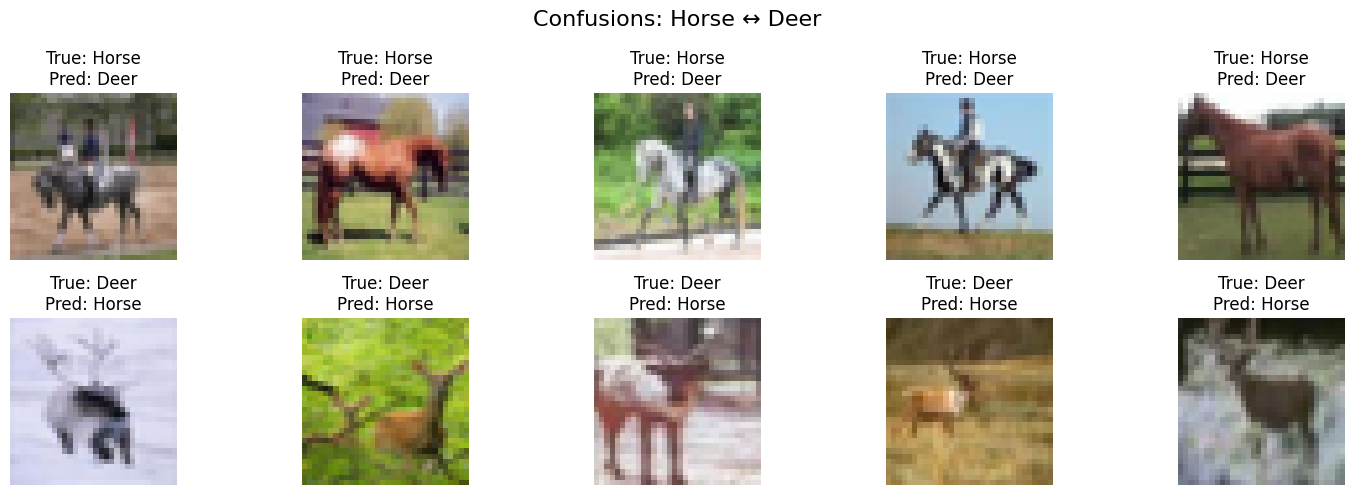

In [37]:
# Make sure y_pred and y_true are numpy arrays
y_pred = np.array(y_pred)
y_true = np.array(y_true)

# Convert X_test to numpy if it's a TensorFlow tensor
X_test_np = X_test.numpy() if hasattr(X_test, 'numpy') else X_test

# Confusing class pairs to inspect
confusing_pairs = [
    (3, 5),  # Cat vs Dog
    (7, 4),  # Horse vs Deer
]

# Function to plot misclassified images between two specific classes
def show_confusion_examples(y_true, y_pred, X, class1, class2, n=5):

    idx_confused_1 = np.where(
        (y_true == class1) & (y_pred == class2)
    )[0]

    idx_confused_2 = np.where(
        (y_true == class2) & (y_pred == class1)
    )[0]

    # Shuffle for variety
    np.random.shuffle(idx_confused_1)
    np.random.shuffle(idx_confused_2)

    fig, axes = plt.subplots(2, n, figsize=(15, 5))
    fig.suptitle(f"Confusions: {class_names[class1]} ↔ {class_names[class2]}", fontsize=16)

    for i in range(n):
        if i < len(idx_confused_1):
            ax = axes[0, i]
            ax.imshow(X[idx_confused_1[i]])
            ax.set_title(f"True: {class_names[class1]}\nPred: {class_names[class2]}")
            ax.axis('off')
        else:
            axes[0, i].axis('off')

        if i < len(idx_confused_2):
            ax = axes[1, i]
            ax.imshow(X[idx_confused_2[i]])
            ax.set_title(f"True: {class_names[class2]}\nPred: {class_names[class1]}")
            ax.axis('off')
        else:
            axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

# Show misclassifications for each confusing pair
for class1, class2 in confusing_pairs:
    show_confusion_examples(y_true, y_pred, X_test_np, class1, class2)

In [82]:
## Final result on evaluation

loss_v2_2_softaug, accuracy_v2_2_softaug = model_v21_softaug.evaluate(X_test, y_test_cat)
print(f"Test accuracy of baseline model: {accuracy_v2_2_softaug:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.8659 - loss: 0.4424
Test accuracy of baseline model: 0.8659


## Mode v3. Adding a dropout layer.

### Model Architecture

In [31]:
#Building model
base_model_v3= DenseNet121(include_top=False, weights ="imagenet", input_shape = (img_height,img_width,3), pooling = "avg")
# Freeze pretrained layers
base_model_v3.trainable = False
model_v3_drop = models.Sequential([
    Input(shape = (32,32,3)),#Indicating the input size of original images
    Resizing(96,96),
    data_augmentationv2,
    Lambda(preprocess_input),
    base_model_v3,
    Dense(128, activation='relu'),#Adding a fully connected layer
    Dropout(0.2),
    Dense(10, activation ="softmax"), #Selecting output to be the size of the classes

])
#Defining the compiler for the model
opt = tf.keras.optimizers.Adam(
    learning_rate=0.001,
    epsilon=1e-07)
model_v3_drop.compile(optimizer=opt,
              loss='categorical_crossentropy',
              metrics=['accuracy'])
#Printing model summary
model_v3_drop.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_3 (Resizing)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_3 (Lambda)               │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 1024)           │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,169,994 (27.35 MB)

 Trainable params: 132,490 (517.54 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

### Model Training

In [32]:
checkpoint = ModelCheckpoint(
    filepath=f'{project_path}/checkpoints/densenetv3_drop/best_model.keras',
    save_best_only=True,  # only saves if model improved
    monitor='val_accuracy',
    verbose=1
)
history_v3_drop= model_v3_drop.fit(X_train,y_train_cat,
          validation_split = 0.2,
          epochs=100, # set high — early stopping will interrupt,
          batch_size=64,
          callbacks=[checkpoint, early_stopping, reduce_lr]
          )

Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.5881 - loss: 1.2592
Epoch 1: val_accuracy improved from None to 0.82640, saving model to /content/drive/MyDrive/cnn_project/checkpoints/densenetv3_drop/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/densenetv3_drop/best_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 66s 88ms/step - accuracy: 0.6739 - loss: 0.9592 - val_accuracy: 0.8264 - val_loss: 0.5087 - learning_rate: 0.0010
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.7432 - loss: 0.7368
Epoch 2: val_accuracy improved from 0.82640 to 0.84230, saving model to /content/drive/MyDrive/cnn_project/checkpoints/densenetv3_drop/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/densenetv3_drop/best_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 49s 78ms/step - accuracy: 0.7456 - loss: 0.7324 - val_accuracy: 0.8423 - val_loss: 0.4598 - learning_rate: 0.0010
Epoch 3

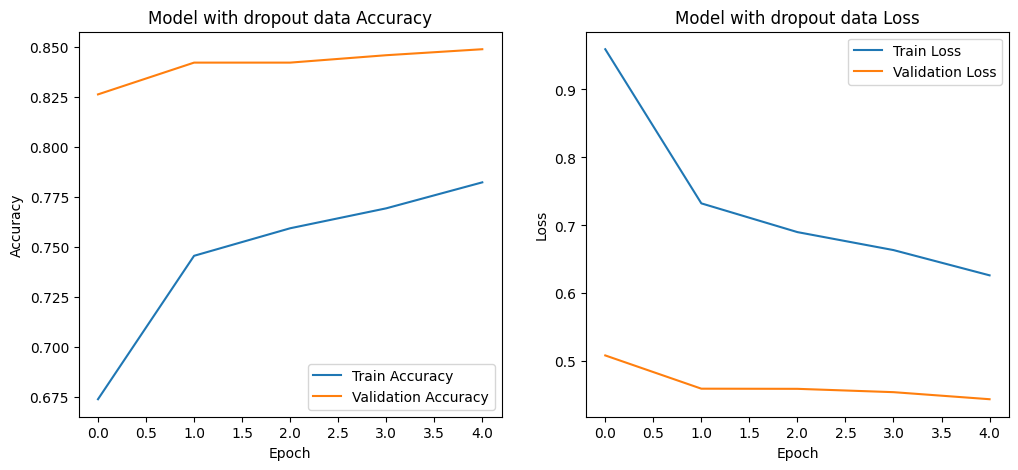

In [33]:
#Plotting results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_v3_drop.history['accuracy'], label='Train Accuracy')
plt.plot(history_v3_drop.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model with dropout data Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_v3_drop.history['loss'], label='Train Loss')
plt.plot(history_v3_drop.history['val_loss'], label='Validation Loss')
plt.title('Model with dropout data Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Evaluation of the model

In [34]:
## Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# Predict class probabilities
y_pred_probs = model_v3_drop.predict(X_test)

# Convert probabilities to class predictions
y_pred = y_pred_probs.argmax(axis=1)
y_true = y_test  # original integer labels

# Compute metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step
Accuracy: 0.8252
Precision: 0.8275
Recall: 0.8252
F1 Score: 0.8238


### Evaluation of test data

In [35]:
## Final result on evaluation

loss_v3_drop, accuracy_v3_drop = model_v3_drop.evaluate(X_test, y_test_cat)
print(f"Test accuracy of baseline model: {accuracy_v3_drop:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.8252 - loss: 0.5157
Test accuracy of baseline model: 0.8252


## Model v4. Regularization

### Model Architecture

In [36]:
#Building model
from tensorflow.keras.regularizers import l2
base_model_v4 = DenseNet121(include_top=False, weights ="imagenet", input_shape =(96,96,3), pooling = "avg")
# Freeze pretrained layers
base_model_v4.trainable = False
model_v4_drop_reg = models.Sequential([
    Input(shape = (32,32,3)),#Indicating the input size of original images
    Resizing(96,96),
    data_augmentationv2,
    Lambda(preprocess_input),
    base_model_v4,
    Dense(128, activation='relu'),#Adding a fully connected layer
    Dropout(0.2),
    Dense(10, activation ="softmax"), #Selecting output to be the size of the classes
])

#Defining the compiler for the model
opt = tf.keras.optimizers.Adam(
    learning_rate=0.001,
    epsilon=1e-07)

model_v4_drop_reg.compile(optimizer=opt,
              loss='categorical_crossentropy',
              metrics=['accuracy'])
#Printing model summary
model_v4_drop_reg.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_4 (Resizing)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_4 (Lambda)               │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 1024)           │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,169,994 (27.35 MB)

 Trainable params: 132,490 (517.54 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [37]:
checkpoint = ModelCheckpoint(
    filepath=f'{project_path}/checkpoints/densenetv4_reg/best_model.keras',
    save_best_only=True,  # only saves if model improved
    monitor='val_accuracy',
    verbose=1
)
history_v4_drop_reg= model_v4_drop_reg.fit(X_train,y_train_cat,
          validation_split = 0.2,
          epochs=100, # set high — early stopping will interrupt,
          batch_size=64,
          callbacks=[checkpoint, early_stopping, reduce_lr]
          )

Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.5896 - loss: 1.2423
Epoch 1: val_accuracy improved from None to 0.82720, saving model to /content/drive/MyDrive/cnn_project/checkpoints/densenetv4_reg/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/densenetv4_reg/best_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 69s 90ms/step - accuracy: 0.6761 - loss: 0.9478 - val_accuracy: 0.8272 - val_loss: 0.5016 - learning_rate: 0.0010
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.7358 - loss: 0.7486
Epoch 2: val_accuracy improved from 0.82720 to 0.82820, saving model to /content/drive/MyDrive/cnn_project/checkpoints/densenetv4_reg/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/densenetv4_reg/best_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 49s 78ms/step - accuracy: 0.7417 - loss: 0.7332 - val_accuracy: 0.8282 - val_loss: 0.5121 - learning_rate: 0.0010
Epoch 3/100

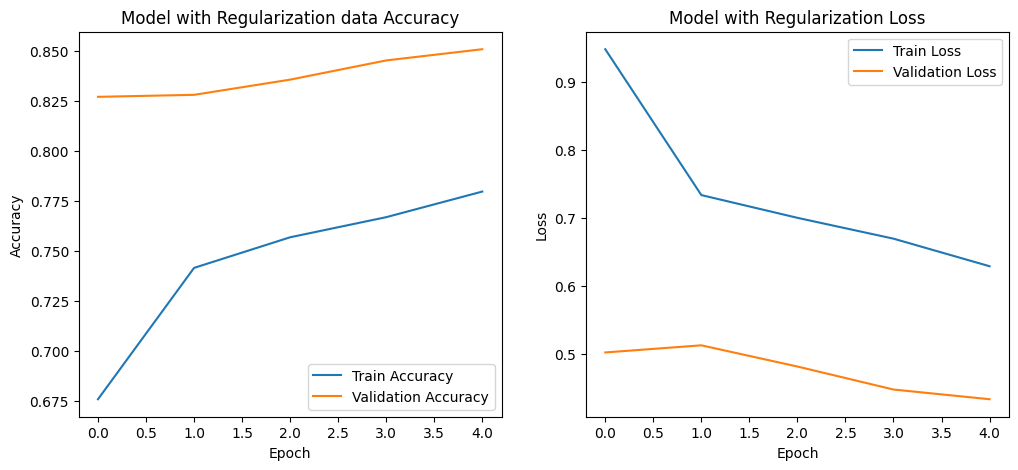

In [38]:
#Plotting results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_v4_drop_reg.history['accuracy'], label='Train Accuracy')
plt.plot(history_v4_drop_reg.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model with Regularization data Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_v4_drop_reg.history['loss'], label='Train Loss')
plt.plot(history_v4_drop_reg.history['val_loss'], label='Validation Loss')
plt.title('Model with Regularization Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [39]:
loss_v4_drop_reg, accuracy_v4_drop_reg = model_v4_drop_reg.evaluate(X_test, y_test_cat)
print(f"Test accuracy of baseline model: {accuracy_v4_drop_reg:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.8270 - loss: 0.5105
Test accuracy of baseline model: 0.8270


## Model v5. decreasing the rough data augmentation

In [40]:
data_augmentation2 = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05)
])

In [41]:
#Building model
from tensorflow.keras.regularizers import l2
base_model_v5 = DenseNet121(include_top=False, weights ="imagenet", input_shape =(96,96,3), pooling = "avg")
# Freeze pretrained layers
base_model_v5.trainable = False
model_v5_softaug = models.Sequential([
    Input(shape = (32,32,3)),#Indicating the input size of original images
    Resizing(96,96),
    data_augmentationv2,
    Lambda(preprocess_input),
    base_model_v5,
    Dense(128, activation='relu'),#Adding a fully connected layer
    Dropout(0.2),
    Dense(10, activation ="softmax"), #Selecting output to be the size of the classes
])

#Defining the compiler for the model
opt = tf.keras.optimizers.Adam(
    learning_rate=0.001,
    epsilon=1e-07)

model_v5_softaug.compile(optimizer=opt,
              loss='categorical_crossentropy',
              metrics=['accuracy'])
#Printing model summary
model_v5_softaug.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_5 (Resizing)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_8 (Sequential)       │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_5 (Lambda)               │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 1024)           │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,169,994 (27.35 MB)

 Trainable params: 132,490 (517.54 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [42]:
checkpoint = ModelCheckpoint(
    filepath=f'{project_path}/checkpoints/densenetv5_softaug/best_model.keras',
    save_best_only=True,  # only saves if model improved
    monitor='val_accuracy',
    verbose=1
)
history_v5_softaug= model_v5_softaug.fit(X_train,y_train_cat,
          validation_split = 0.2,
          epochs=100, # set high — early stopping will interrupt,
          batch_size=64,
          callbacks=[checkpoint, early_stopping, reduce_lr]
          )

Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.6792 - loss: 1.0065
Epoch 1: val_accuracy improved from None to 0.84710, saving model to /content/drive/MyDrive/cnn_project/checkpoints/densenetv5_softaug/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/densenetv5_softaug/best_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 72s 90ms/step - accuracy: 0.7553 - loss: 0.7331 - val_accuracy: 0.8471 - val_loss: 0.4515 - learning_rate: 0.0010
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.8117 - loss: 0.5447
Epoch 2: val_accuracy improved from 0.84710 to 0.84890, saving model to /content/drive/MyDrive/cnn_project/checkpoints/densenetv5_softaug/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/densenetv5_softaug/best_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 49s 79ms/step - accuracy: 0.8141 - loss: 0.5363 - val_accuracy: 0.8489 - val_loss: 0.4372 - learning_rate: 0.

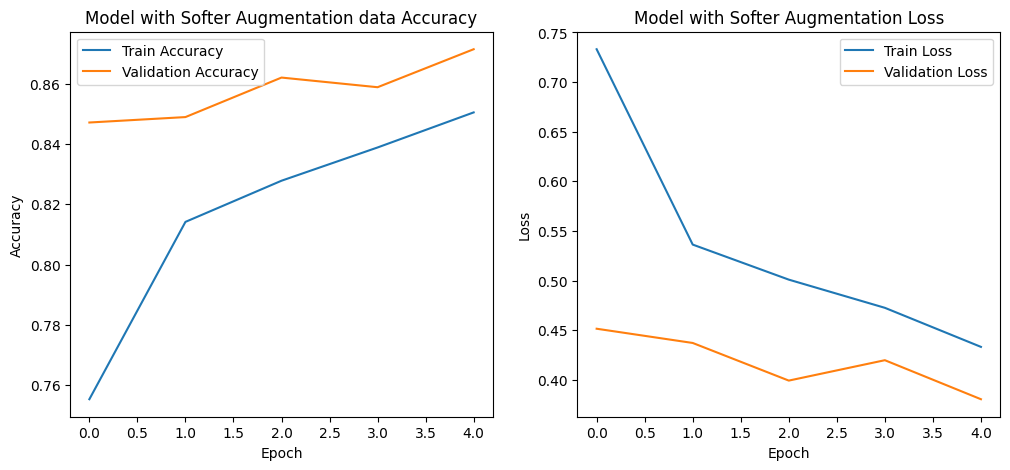

In [43]:
#Plotting results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_v5_softaug.history['accuracy'], label='Train Accuracy')
plt.plot(history_v5_softaug.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model with Softer Augmentation data Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_v5_softaug.history['loss'], label='Train Loss')
plt.plot(history_v5_softaug.history['val_loss'], label='Validation Loss')
plt.title('Model with Softer Augmentation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [45]:
loss_v5_softaug, accuracy_v5_softaug = model_v5_softaug.evaluate(X_test, y_test_cat)
print(f"Test accuracy of baseline model: {accuracy_v5_softaug:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.8357 - loss: 0.4665
Test accuracy of baseline model: 0.8357


## Model V6. Dense to 64

In [91]:
#Building model
from tensorflow.keras.regularizers import l2
base_model_v6 = DenseNet121(include_top=False, weights ="imagenet", input_shape =(96,96,3), pooling = "avg")
# Freeze pretrained layers
base_model_v6.trainable = False
model_v6_dense64 = models.Sequential([
    Input(shape = (32,32,3)),#Indicating the input size of original images
    Resizing(96,96),
    data_augmentationv2,
    Lambda(preprocess_input),
    base_model_v6,
    Dense(64, activation='relu'),#Adding a fully connected layer
    Dropout(0.2),
    Dense(10, activation ="softmax"), #Selecting output to be the size of the classes
])

#Defining the compiler for the model
opt = tf.keras.optimizers.Adam(
    learning_rate=0.001,
    epsilon=1e-07)

model_v6_dense64.compile(optimizer=opt,
              loss='categorical_crossentropy',
              metrics=['accuracy'])
#Printing model summary
model_v6_dense64.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_12 (Resizing)          │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_12 (Sequential)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_12 (Lambda)              │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 1024)           │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,103,754 (27.10 MB)

 Trainable params: 66,250 (258.79 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [ ]:
checkpoint = ModelCheckpoint(
    filepath=f'{project_path}/checkpoints/densenetv6_dense64/best_model.keras',
    save_best_only=True,  # only saves if model improved
    monitor='val_accuracy',
    verbose=1
)
history_v6_dense64= model_v6_dense64.fit(X_train,y_train_cat,
          validation_split = 0.2,
          epochs=100, # set high — early stopping will interrupt,
          batch_size=64,
          callbacks=[checkpoint, early_stopping, reduce_lr]
          )

In [ ]:
#Plotting results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_v6_dense64.history['accuracy'], label='Train Accuracy')
plt.plot(history_v6_dense64.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model with Softer Augmentation data Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_v6_dense64.history['loss'], label='Train Loss')
plt.plot(history_v6_dense64.history['val_loss'], label='Validation Loss')
plt.title('Model with Softer Augmentation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
loss_v6_dense64, accuracy_v6_dense64 = model_v6_dense64.evaluate(X_test, y_test_cat)
print(f"Test accuracy of baseline model: {accuracy_v6_dense64:.4f}")

## Model v7. Global Avg pooling

In [86]:
#Building model
from tensorflow.keras.regularizers import l2
base_model_v7_2 = DenseNet121(include_top=False, weights ="imagenet", input_shape =(96,96,3))
# Freeze pretrained layers
base_model_v7_2.trainable = False
model_v7_avg = models.Sequential([
    Input(shape = (32,32,3)),#Indicating the input size of original images
    Resizing(96,96),
    data_augmentationv2,
    Lambda(preprocess_input),
    base_model_v7_2,
    GlobalAveragePooling2D(),
    Dropout(0.2),
    Dense(10, activation ="softmax"), #Selecting output to be the size of the classes
])

#Defining the compiler for the model
opt = tf.keras.optimizers.Adam(
    learning_rate=0.001,
    epsilon=1e-07)

model_v7_avg.compile(optimizer=opt,
              loss='categorical_crossentropy',
              metrics=['accuracy'])
#Printing model summary
model_v7_avg.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_11 (Resizing)          │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_12 (Sequential)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_11 (Lambda)              │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 3, 3, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,047,754 (26.89 MB)

 Trainable params: 10,250 (40.04 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [87]:
checkpoint = ModelCheckpoint(
    filepath=f'{project_path}/checkpoints/densenetv7_avg/best_model.keras',
    save_best_only=True,  # only saves if model improved
    monitor='val_accuracy',
    verbose=1
)
history_v7_avg= model_v7_avg.fit(X_train,y_train_cat,
          validation_split = 0.2,
          epochs=100, # set high — early stopping will interrupt,
          batch_size=64,
          callbacks=[checkpoint, early_stopping, reduce_lr]
          )

Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.6259 - loss: 1.2942
Epoch 1: val_accuracy improved from None to 0.84370, saving model to /content/drive/MyDrive/cnn_project/checkpoints/densenetv7_avg/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/densenetv7_avg/best_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 71s 88ms/step - accuracy: 0.7426 - loss: 0.8309 - val_accuracy: 0.8437 - val_loss: 0.4714 - learning_rate: 0.0010
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.8248 - loss: 0.5307
Epoch 2: val_accuracy improved from 0.84370 to 0.85520, saving model to /content/drive/MyDrive/cnn_project/checkpoints/densenetv7_avg/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/densenetv7_avg/best_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 80ms/step - accuracy: 0.8255 - loss: 0.5283 - val_accuracy: 0.8552 - val_loss: 0.4371 - learning_rate: 0.0010
Epoch 3/100

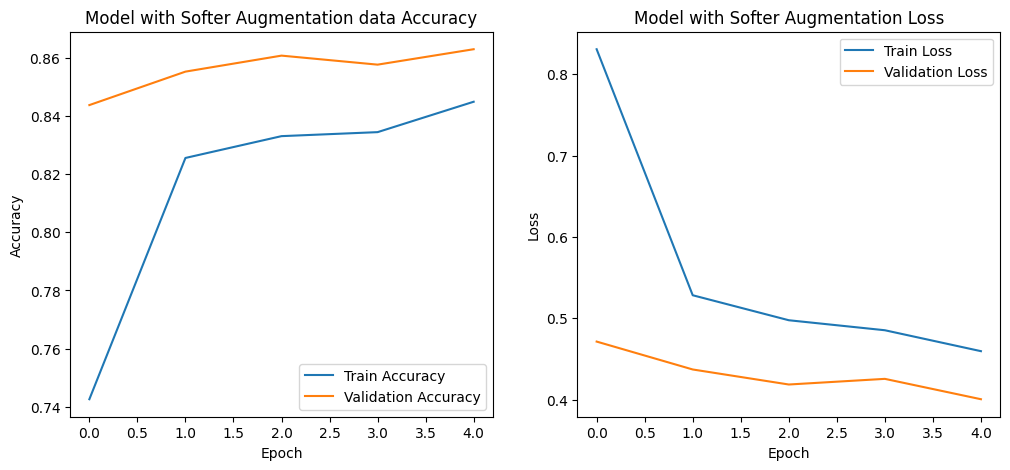

In [88]:
#Plotting results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_v7_avg.history['accuracy'], label='Train Accuracy')
plt.plot(history_v7_avg.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model with Softer Augmentation data Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_v7_avg.history['loss'], label='Train Loss')
plt.plot(history_v7_avg.history['val_loss'], label='Validation Loss')
plt.title('Model with Softer Augmentation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [89]:
loss_v7_avg, accuracy_v7_avg = model_v7_avg.evaluate(X_test, y_test_cat)
print(f"Test accuracy of baseline model: {accuracy_v7_avg:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.8354 - loss: 0.4968
Test accuracy of baseline model: 0.8354


## Summary of model iterations


In [52]:
import pandas as pd

In [85]:
model_accuracy_loss = {
"Model v1" : {"accuracy": accuracy_v1, "loss":loss_v1},
"Model v2" : {"accuracy": accuracy_v2_aug, "loss":loss_v2_aug},
"Model v2.2" : {"accuracy":accuracy_v2_2_softaug , "loss":loss_v2_2_softaug},
"Model v3" : {"accuracy": accuracy_v3_drop, "loss":loss_v3_drop},
"Model v4" : {"accuracy": accuracy_v4_drop_reg, "loss":loss_v4_drop_reg},
"Model v5" : {"accuracy": accuracy_v5_softaug, "loss":loss_v5_softaug},
#"Model v6" : {"accuracy": accuracy_v6_dense64, "loss":loss_v6_dense64},
"Model v7" : {"accuracy": accuracy_v7_avg, "loss":loss_v7_avg},
}

df_accuracy_loss = pd.DataFrame.from_dict(model_accuracy_loss,orient="index")
df_accuracy_loss.index.name = "Model"
df_accuracy_loss.reset_index(inplace=True)
df_accuracy_loss


,Model,accuracy,loss
0,Model v1,0.8618,0.436778
1,Model v2,0.8542,0.427764
2,Model v2.2,0.8659,0.442353
3,Model v3,0.8252,0.515711
4,Model v4,0.8270,0.510470
5,Model v5,0.8357,0.466521
6,Model v7,0.8304,0.498425


In [62]:
def evaluation_metrics(model, X_test,y_test):
  from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
  # Predict class probabilities
  y_pred_probs = model.predict(X_test)

  # Convert probabilities to class predictions
  y_pred = y_pred_probs.argmax(axis=1)
  y_true = y_test  # original integer labels

  # Compute metrics
  acc = accuracy_score(y_true, y_pred)
  prec = precision_score(y_true, y_pred, average='weighted')
  rec = recall_score(y_true, y_pred, average='weighted')
  f1 = f1_score(y_true, y_pred, average='weighted')

  summary = {
  "Accuracy": acc,
  "Precision": prec,
  "Recall": rec,
  "F1 Score": f1,
  }
  return summary


In [65]:
metrics = {
"metrics_v1" : evaluation_metrics(model_v1, X_test, y_test),
"metrics_v2" : evaluation_metrics(model_v2_aug, X_test, y_test),
"metrics_v2.2" : evaluation_metrics(model_v2_2_softaug, X_test, y_test),
"metrics_v2.2" : evaluation_metrics(model_v3_drop, X_test, y_test),
"metrics_v4" : evaluation_metrics(model_v4_drop_reg, X_test, y_test),
"metrics_v5" : evaluation_metrics(model_v5_softaug, X_test, y_test),
#"metrics_v6" : evaluation_metrics(model_v6_dense64, X_test, y_test),
"metrics_v7" : evaluation_metrics(model_v7_avg, X_test, y_test),
}


313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step


In [66]:
df_metrics = pd.DataFrame.from_dict(metrics)
df_metrics

,metrics_v1,metrics_v2,metrics_v2.2,metrics_v4,metrics_v5,metrics_v7
Accuracy,0.861800,0.854200,0.825200,0.827000,0.835700,0.830400
Precision,0.863039,0.855889,0.827514,0.828444,0.837652,0.831989
Recall,0.861800,0.854200,0.825200,0.827000,0.835700,0.830400
F1 Score,0.861169,0.853028,0.823787,0.826051,0.835281,0.829599


# Fine tuning

In [68]:
dense_model = DenseNet121()
for i, layer in enumerate(dense_model.layers):
    print(i, layer.name)

33188688/33188688 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
0 input_layer_18
1 zero_padding2d_16
2 conv1_conv
3 conv1_bn
4 conv1_relu
5 zero_padding2d_17
6 pool1
7 conv2_block1_0_bn
8 conv2_block1_0_relu
9 conv2_block1_1_conv
10 conv2_block1_1_bn
11 conv2_block1_1_relu
12 conv2_block1_2_conv
13 conv2_block1_concat
14 conv2_block2_0_bn
15 conv2_block2_0_relu
16 conv2_block2_1_conv
17 conv2_block2_1_bn
18 conv2_block2_1_relu
19 conv2_block2_2_conv
20 conv2_block2_concat
21 conv2_block3_0_bn
22 conv2_block3_0_relu
23 conv2_block3_1_conv
24 conv2_block3_1_bn
25 conv2_block3_1_relu
26 conv2_block3_2_conv
27 conv2_block3_concat
28 conv2_block4_0_bn
29 conv2_block4_0_relu
30 conv2_block4_1_conv
31 conv2_block4_1_bn
32 conv2_block4_1_relu
33 conv2_block4_2_conv
34 conv2_block4_concat
35 conv2_block5_0_bn
36 conv2_block5_0_relu
37 conv2_block5_1_conv
38 conv2_block5_1_bn
39 conv2_block5_1_relu
40 conv2_block5_2_conv
41 conv2_block5_concat
42 conv2_block6_0_bn
43 conv2_block6_0_relu
44 conv2_block6_1_con

In [45]:
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras import optimizers
model_v21_fine = tf.keras.models.load_model(
    "/content/drive/MyDrive/cnn_project/checkpoints/densenet2v21_softaug/best_model.keras",
    custom_objects={
        "preprocess_input": preprocess_input
    }
)
#Finetuning #1
base_model_v21 = model_v21_fine.get_layer("densenet121")
# Unfreeze last layers of base model for fine-tuning
base_model_v21.trainable = True

# Freeze the last denseblock
N = 40
fine_tune_at = len(base_model_v21.layers) - N
for layer in base_model_v21.layers[:fine_tune_at]:
    layer.trainable = False

# Compile model with a lower learning rate
learning_rate = 1e-5
model_v21_fine.compile(
    optimizer=optimizers.Adam(learning_rate=learning_rate),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Continue training (fine-tuning)
fine_tune_epochs = 15
total_epochs = 10 + fine_tune_epochs  # if trained earlier 3 epochs

#Creating directory
experiment_name = f"lr{learning_rate}_unfreeze{N}"

save_dir = f"{project_path}/checkpoints/{experiment_name}"


#Controling and training the model
checkpoint = ModelCheckpoint(
    filepath=f'{save_dir}/best_model.keras',
    save_best_only=True,  # only saves if model improved
    monitor='val_accuracy',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=5,        # stops if no improvement for 5 epochs
    restore_best_weights=True,  # rolls back to best weights when stopping
    verbose=1
)

history_v21fine = model_v21_fine.fit(
    X_train, y_train_cat,
    validation_split=0.2,
    epochs=total_epochs,
    initial_epoch=3,
    batch_size=64,
    callbacks = [early_stopping, checkpoint]
)


Epoch 4/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.8497 - loss: 0.4277
Epoch 4: val_accuracy improved from None to 0.86070, saving model to /content/drive/MyDrive/cnn_project/checkpoints/lr1e-05_unfreeze40/best_model.keras

Epoch 4: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/lr1e-05_unfreeze40/best_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 75s 94ms/step - accuracy: 0.8674 - loss: 0.3825 - val_accuracy: 0.8607 - val_loss: 0.4040
Epoch 5/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.8903 - loss: 0.3219
Epoch 5: val_accuracy improved from 0.86070 to 0.86520, saving model to /content/drive/MyDrive/cnn_project/checkpoints/lr1e-05_unfreeze40/best_model.keras

Epoch 5: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/lr1e-05_unfreeze40/best_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 89ms/step - accuracy: 0.8906 - loss: 0.3211 - val_accuracy: 0.8652 - val_loss: 0.3885
Epoch 6/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 70

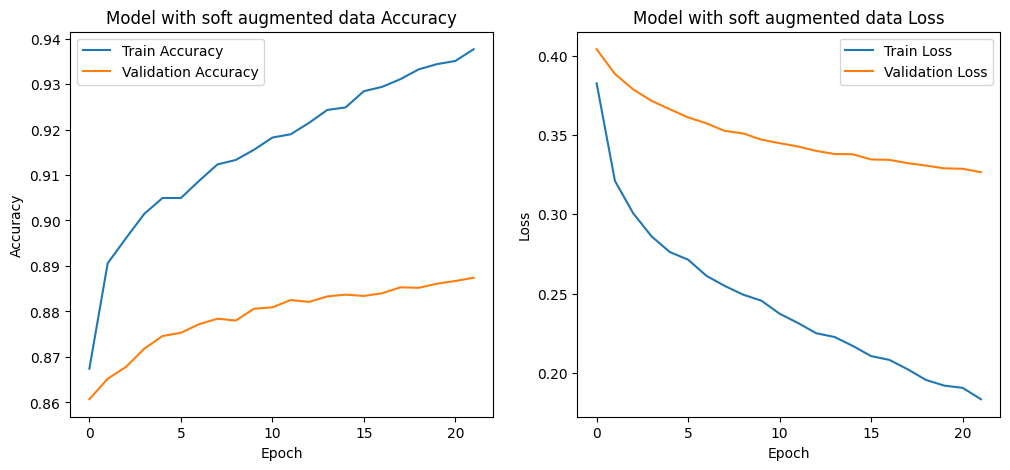

In [47]:
#Plotting results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_v21fine.history['accuracy'], label='Train Accuracy')
plt.plot(history_v21fine.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model with soft augmented data Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_v21fine.history['loss'], label='Train Loss')
plt.plot(history_v21fine.history['val_loss'], label='Validation Loss')
plt.title('Model with soft augmented data Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [48]:
# Evaluate
test_loss_v21_fine, test_acc_v21_fine = model_v21_fine.evaluate(X_test, y_test_cat)
print(f"Test Accuracy after fine-tuning: {test_acc_v21_fine:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.8833 - loss: 0.3409
Test Accuracy after fine-tuning: 0.8833


In [49]:
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras import optimizers
model_v21_fine_block = tf.keras.models.load_model(
    "/content/drive/MyDrive/cnn_project/checkpoints/densenet2v21_softaug/best_model.keras",
    custom_objects={
        "preprocess_input": preprocess_input
    }
)
#Finetuning #1
base_model_v21_block = model_v21_fine_block.get_layer("densenet121")
# Unfreeze last layers of base model for fine-tuning
base_model_v21_block.trainable = True

# Freeze the last denseblock
#everything with conv5
for layer in base_model_v21_block.layers:

    # Freeze only conv5 layers
    if "conv5" in layer.name:
        layer.trainable = False
    else:
        layer.trainable = True

# Compile model with a lower learning rate
learning_rate = 1e-5
model_v21_fine_block.compile(
    optimizer=optimizers.Adam(learning_rate=learning_rate),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Continue training (fine-tuning)
fine_tune_epochs = 15
total_epochs = 10 + fine_tune_epochs  # if trained earlier 3 epochs

#Creating directory
experiment_name = f"lr{learning_rate}_unfreeze-block"

save_dir = f"{project_path}/checkpoints/{experiment_name}"


#Controling and training the model
checkpoint = ModelCheckpoint(
    filepath=f'{save_dir}/best_model.keras',
    save_best_only=True,  # only saves if model improved
    monitor='val_accuracy',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=5,        # stops if no improvement for 5 epochs
    restore_best_weights=True,  # rolls back to best weights when stopping
    verbose=1
)

history_v21fine_block = model_v21_fine_block.fit(
    X_train, y_train_cat,
    validation_split=0.2,
    epochs=total_epochs,
    initial_epoch=3,
    batch_size=64,
    callbacks = [early_stopping, checkpoint]
)

Epoch 4/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.7789 - loss: 0.6517
Epoch 4: val_accuracy improved from None to 0.88180, saving model to /content/drive/MyDrive/cnn_project/checkpoints/lr1e-05_unfreeze-block/best_model.keras

Epoch 4: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/lr1e-05_unfreeze-block/best_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 226s 284ms/step - accuracy: 0.8432 - loss: 0.4590 - val_accuracy: 0.8818 - val_loss: 0.3512
Epoch 5/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step - accuracy: 0.9036 - loss: 0.2778
Epoch 5: val_accuracy improved from 0.88180 to 0.90620, saving model to /content/drive/MyDrive/cnn_project/checkpoints/lr1e-05_unfreeze-block/best_model.keras

Epoch 5: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/lr1e-05_unfreeze-block/best_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 173s 277ms/step - accuracy: 0.9090 - loss: 0.2606 - val_accuracy: 0.9062 - val_loss: 0.2693
Epoch 6/25
625/625 ━━━━

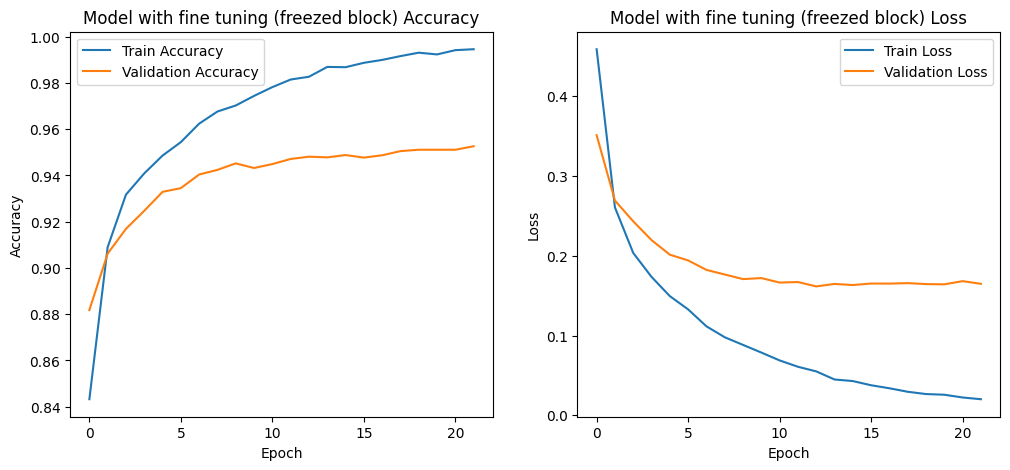

In [50]:
#Plotting results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_v21fine_block.history['accuracy'], label='Train Accuracy')
plt.plot(history_v21fine_block.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model with fine tuning (freezed block) Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_v21fine_block.history['loss'], label='Train Loss')
plt.plot(history_v21fine_block.history['val_loss'], label='Validation Loss')
plt.title('Model with fine tuning (freezed block) Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [53]:
## Evaluation code:

#Printing evaluation metrics on test data

# Predict class probabilities
y_pred_probs = model_v21_fine_block.predict(X_test)

# Convert probabilities to class predictions
y_pred = y_pred_probs.argmax(axis=1)
y_true = y_test  # original integer labels

# Compute metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 45ms/step
Accuracy: 0.9534
Precision: 0.9535
Recall: 0.9534
F1 Score: 0.9534


In [52]:
# Evaluate
test_loss_v21_fine_block, test_acc_v21_fine_block = model_v21_fine_block.evaluate(X_test, y_test_cat)
print(f"Test Accuracy after fine-tuning: {test_acc_v21_fine_block:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.9534 - loss: 0.1605
Test Accuracy after fine-tuning: 0.9534
